In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import seaborn as sns
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
source_dir = r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta"
output_dir = r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas"

train_ratio = 0.7
val_ratio = 0.10
test_ratio = 0.20

classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
   class_path = os.path.join(source_dir, cls)
   images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
   
   train_imgs, temp_imgs = train_test_split(
       images, 
       test_size=(val_ratio + test_ratio), 
       random_state=1
   )
   
   relative_test_size = test_ratio / (val_ratio + test_ratio)
   val_imgs, test_imgs = train_test_split(
       temp_imgs, 
       test_size=relative_test_size, 
       random_state=1
   )
   
   splits = {
       'train': train_imgs, 
       'val': val_imgs, 
       'test': test_imgs
   }
   
   for split_name, split_imgs in splits.items():
       destination_path = os.path.join(output_dir, split_name, cls)
       os.makedirs(destination_path, exist_ok=True)
       
       for img in split_imgs:
           shutil.copy(os.path.join(class_path, img), os.path.join(destination_path, img))
           
   print(f"Class '{cls}': Total {len(images)} images -> Split into {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test.")

print("\nData splitting complete! All data preserved.")

Class 'Buenas': Total 268 images -> Split into 187 train, 27 val, 54 test.
Class 'Malas o rotas': Total 36 images -> Split into 25 train, 3 val, 8 test.

Data splitting complete! All data preserved.


In [3]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas\val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Fotos planta mezcladas\test",
    image_size=IMG_SIZE, # Make sure this matches your model (e.g., (224, 224) or (100, 100))
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Keep false for test data so your evaluation metrics align perfectly
)

all_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0).flatten()
counter = Counter(all_labels)
total_samples = len(all_labels)

class_weight = {
    0: total_samples / (2.0 * counter[0.0]),
    1: total_samples / (2.0 * counter[1.0])
}

print(f"Calculated Class Weights to balance the loss function: {class_weight}")


Found 278 files belonging to 2 classes.
Found 85 files belonging to 2 classes.
Found 102 files belonging to 2 classes.
Calculated Class Weights to balance the loss function: {0: 0.5650406504065041, 1: 4.34375}


In [4]:
model= models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 64)        36928     
                                                                 
 flatten (Flatten)           (None, 28224)             0

In [5]:
history = model.fit(train_ds, validation_data=val_ds, epochs=100, class_weight=class_weight)

test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Epoch 1/100
9/9 [==============================] - 4s 134ms/step - loss: 45.6386 - accuracy: 0.4820 - val_loss: 0.3262 - val_accuracy: 0.8706
Epoch 2/100
9/9 [==============================] - 1s 56ms/step - loss: 0.4677 - accuracy: 0.7986 - val_loss: 0.2436 - val_accuracy: 0.9529
Epoch 3/100
9/9 [==============================] - 1s 44ms/step - loss: 0.4637 - accuracy: 0.8597 - val_loss: 0.2756 - val_accuracy: 0.9059
Epoch 4/100
9/9 [==============================] - 1s 42ms/step - loss: 0.2860 - accuracy: 0.9281 - val_loss: 0.2828 - val_accuracy: 0.8235
Epoch 5/100
9/9 [==============================] - 1s 41ms/step - loss: 0.1600 - accuracy: 0.9676 - val_loss: 0.1702 - val_accuracy: 0.9294
Epoch 6/100
9/9 [==============================] - 1s 40ms/step - loss: 0.0784 - accuracy: 0.9712 - val_loss: 0.2881 - val_accuracy: 0.8941
Epoch 7/100
9/9 [==============================] - 1s 41ms/step - loss: 0.0474 - accuracy: 0.9748 - val_loss: 0.1336 - val_accuracy: 0.9529
Epoch 8/100
9/9 [=

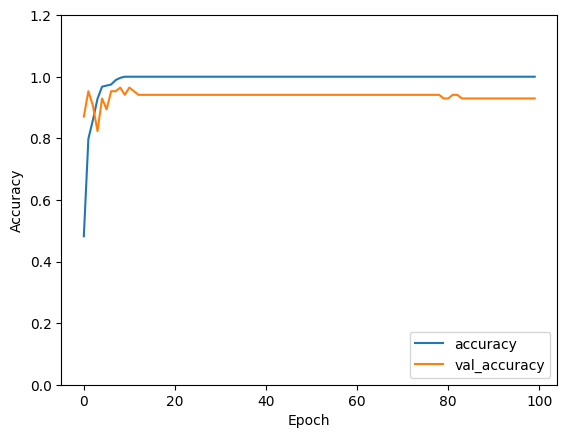

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.2])
plt.legend(loc='lower right')
plt.show()

4/4 [==============================] - 0s 7ms/step
True labels array size: 102
Predicted labels array size: 102


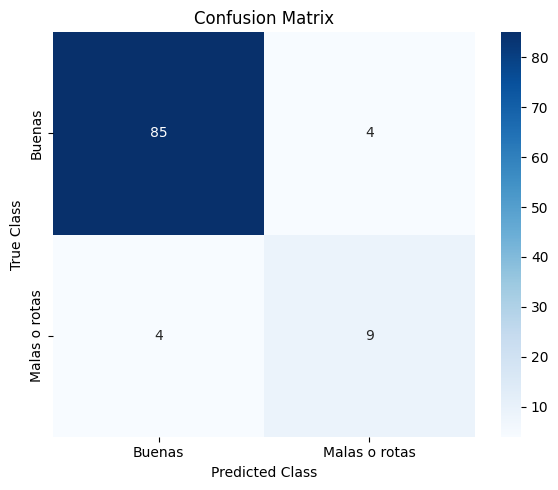


Classification Report:

               precision    recall  f1-score   support

       Buenas       0.96      0.96      0.96        89
Malas o rotas       0.69      0.69      0.69        13

     accuracy                           0.92       102
    macro avg       0.82      0.82      0.82       102
 weighted avg       0.92      0.92      0.92       102



In [ ]:
test_images = []
true_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

test_images = np.concatenate(test_images, axis=0)
true_labels = np.concatenate(true_labels, axis=0).flatten().astype(int)

predictions = model.predict(test_images)

predicted_labels = (predictions > 0.5).astype(int).flatten()

print(f"True labels array size: {true_labels.shape[0]}")
print(f"Predicted labels array size: {predicted_labels.shape[0]}")

cm = confusion_matrix(true_labels, predicted_labels)

class_names = test_ds.class_names 

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

In [ ]:
model.save('CNN_sep_framb(s1-7-1-2-e100).keras')

# 2. Later, in a different script or session, load it back
#from tensorflow import keras
#loaded_model = keras.models.load_model('my_best_raspberry_model.keras')